1 — Chargement des données nettoyées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

df_renouv = pd.read_csv("data/renouvelables_clean.csv")
df_elec = pd.read_csv("data/electricite_clean.csv")

print(f"✅ Renouvelables : {len(df_renouv)} lignes · {len(df_renouv.columns)} colonnes")
print(f"✅ Électricité   : {len(df_elec)} lignes · {len(df_elec.columns)} colonnes")

✅ Renouvelables : 150 lignes · 7 colonnes
✅ Électricité   : 120 lignes · 7 colonnes


2 — Analyse par pays et région

ANALYSE PAR PAYS — Moyenne 2007-2021
country
Sweden         49.3
Austria        33.4
Denmark        29.0
Spain          15.3
Italy          14.9
Germany        14.0
France         13.2
Poland         11.6
Belgium         8.2
Netherlands     6.2
Name: renouvelables_pct, dtype: float64


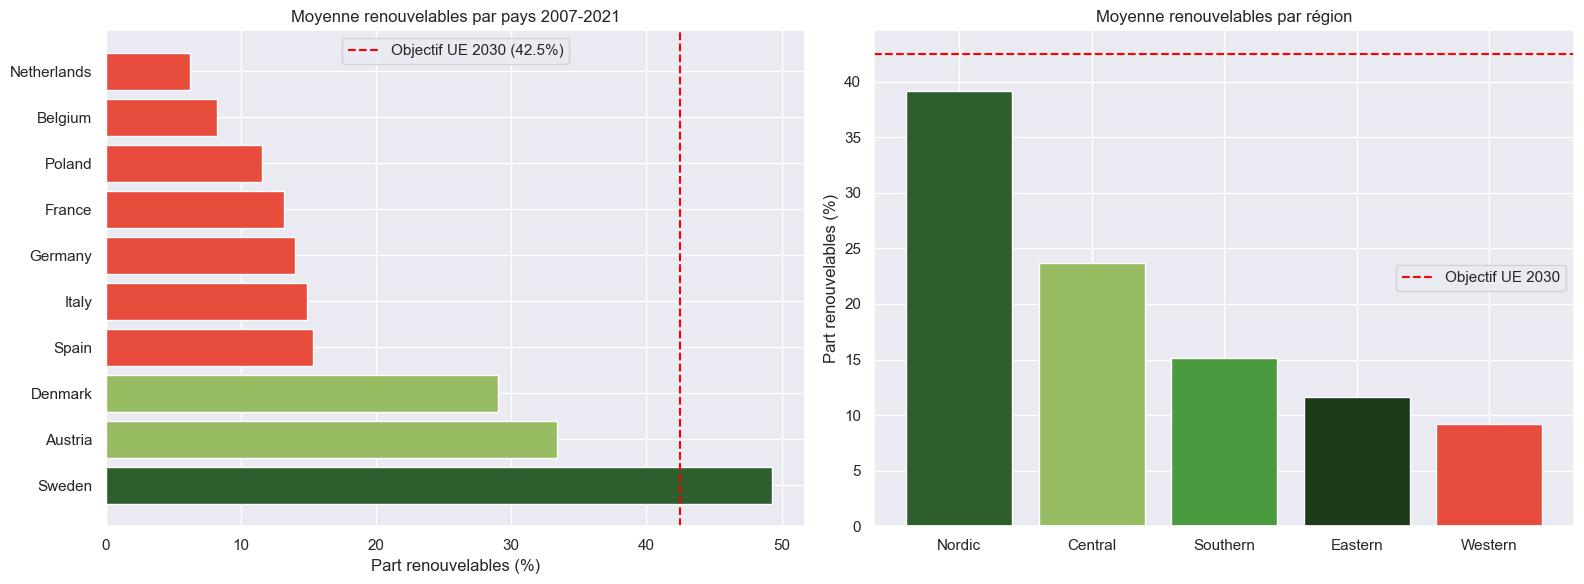

In [2]:
print("ANALYSE PAR PAYS — Moyenne 2007-2021")
print("=" * 50)
moy_pays = df_renouv.groupby("country")["renouvelables_pct"].mean().round(1).sort_values(ascending=False)
print(moy_pays)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Moyenne par pays
colors = ["#2C5F2D" if v >= 42.5 else "#97BC62" if v >= 20 else "#e74c3c" for v in moy_pays.values]
axes[0].barh(moy_pays.index, moy_pays.values, color=colors)
axes[0].axvline(x=42.5, color="red", linestyle="--", label="Objectif UE 2030 (42.5%)")
axes[0].set_title("Moyenne renouvelables par pays 2007-2021")
axes[0].set_xlabel("Part renouvelables (%)")
axes[0].legend()

# Graphique 2 : Moyenne par région
moy_region = df_renouv.groupby("region")["renouvelables_pct"].mean().round(1).sort_values(ascending=False)
axes[1].bar(moy_region.index, moy_region.values, color=["#2C5F2D","#97BC62","#4A9B3F","#1A3A1A","#e74c3c"])
axes[1].axhline(y=42.5, color="red", linestyle="--", label="Objectif UE 2030")
axes[1].set_title("Moyenne renouvelables par région")
axes[1].set_ylabel("Part renouvelables (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

Ce qu'on observe :

Sweden seul pays au-dessus de l'objectif UE 42.5%
Nordic largement en tête par région (~39%)
Western (France, Belgium, Netherlands) — la région la plus en retard !
Tous les pays en rouge sont sous les 20%

3 — Évolution temporelle et tendances

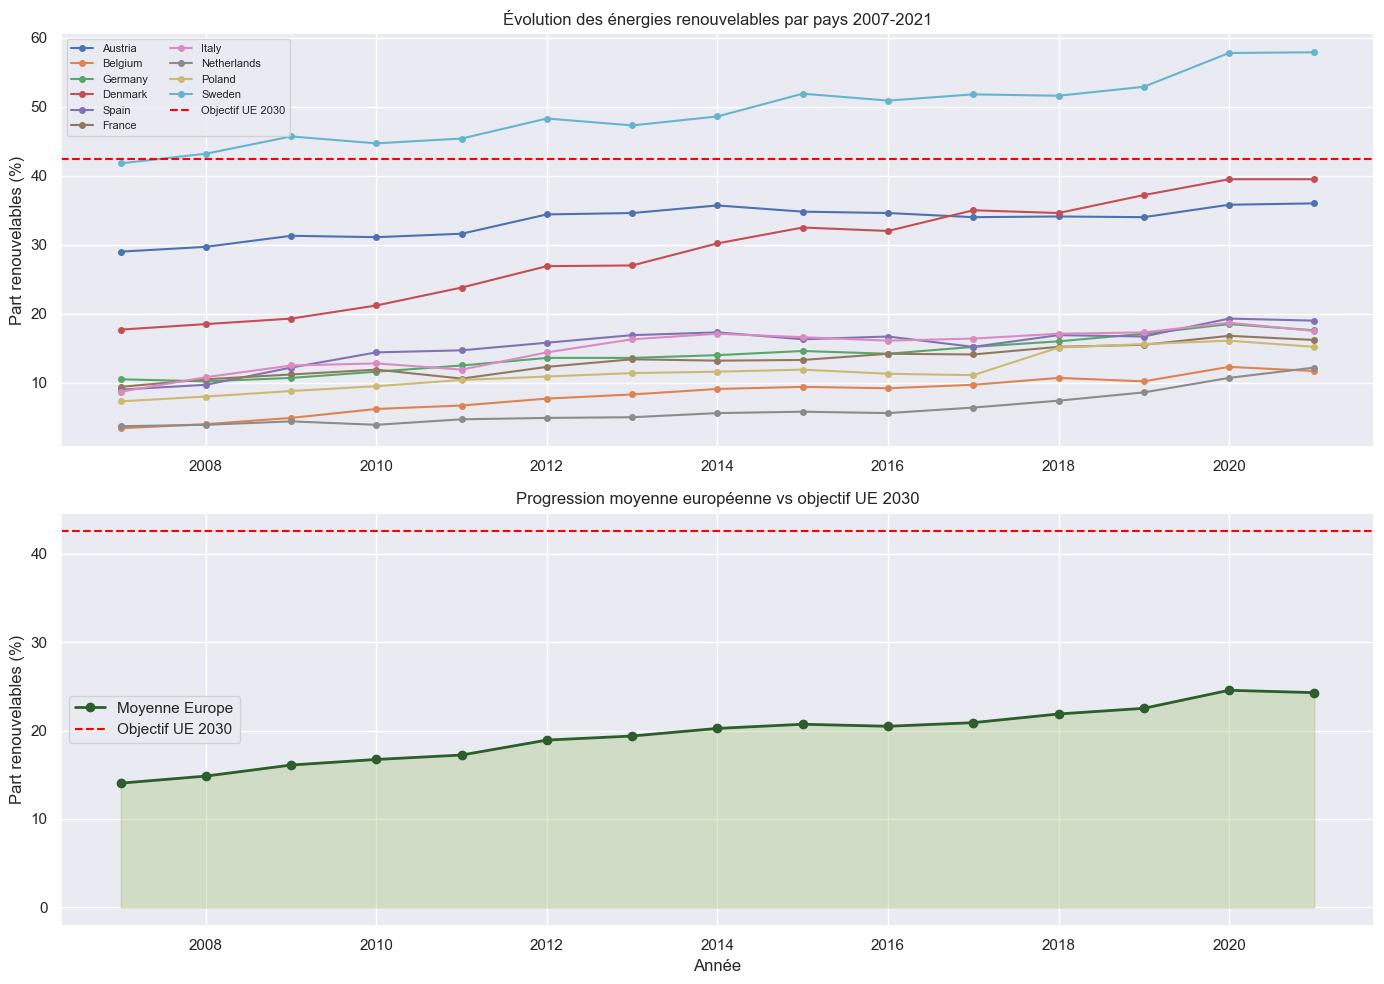

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Évolution par pays
for country in df_renouv["country"].unique():
    data = df_renouv[df_renouv["country"] == country]
    axes[0].plot(data["year"], data["renouvelables_pct"], 
                 marker="o", markersize=4, label=country)
axes[0].axhline(y=42.5, color="red", linestyle="--", linewidth=1.5, label="Objectif UE 2030")
axes[0].set_title("Évolution des énergies renouvelables par pays 2007-2021")
axes[0].set_ylabel("Part renouvelables (%)")
axes[0].legend(fontsize=8, ncol=2)

# Graphique 2 : Moyenne européenne vs objectif
moy_annuelle = df_renouv.groupby("year")["renouvelables_pct"].mean().reset_index()
axes[1].plot(moy_annuelle["year"], moy_annuelle["renouvelables_pct"], 
             marker="o", color="#2C5F2D", linewidth=2, label="Moyenne Europe")
axes[1].fill_between(moy_annuelle["year"], moy_annuelle["renouvelables_pct"], 
                      alpha=0.3, color="#97BC62")
axes[1].axhline(y=42.5, color="red", linestyle="--", linewidth=1.5, label="Objectif UE 2030")
axes[1].set_title("Progression moyenne européenne vs objectif UE 2030")
axes[1].set_ylabel("Part renouvelables (%)")
axes[1].set_xlabel("Année")
axes[1].legend()

plt.tight_layout()
plt.show()

Ce qu'on observe :

La moyenne européenne est passée de ~15% en 2007 à ~25% en 2021
L'objectif UE 2030 à 42.5% est encore loin — il faut presque doubler le rythme
Sweden est le seul pays au-dessus de l'objectif
Denmark et Austria progressent rapidement

4 — Sauvegarde et conclusions

In [4]:
# Sauvegarde données analysées
df_renouv.to_csv("data/renouvelables_analyse.csv", index=False)
df_elec.to_csv("data/electricite_analyse.csv", index=False)

print("✅ Données d'analyse sauvegardées !")

print("\n=== CONCLUSIONS CLÉS ===")
print("=" * 50)

# Progression globale
debut = df_renouv[df_renouv["year"]==2007]["renouvelables_pct"].mean()
fin = df_renouv[df_renouv["year"]==2021]["renouvelables_pct"].mean()
print(f"1. Progression moyenne EU : {debut:.1f}% (2007) → {fin:.1f}% (2021) = +{fin-debut:.1f}pts")

# Pays au-dessus objectif
au_dessus = df_renouv[df_renouv["year"]==2021]
au_dessus = au_dessus[au_dessus["renouvelables_pct"] >= 42.5]["country"].tolist()
print(f"2. Pays au-dessus objectif UE 2030 : {au_dessus}")

# Meilleure progression
prog = df_renouv.groupby("country").apply(
    lambda x: x[x["year"]==2021]["renouvelables_pct"].values[0] - 
              x[x["year"]==2007]["renouvelables_pct"].values[0]
).sort_values(ascending=False)
print(f"3. Meilleures progressions :")
print(prog.head(3).round(1))

# Corrélation entre les deux indicateurs
merged = df_renouv[df_renouv["year"]>=2010].merge(
    df_elec[["country","year","elec_renouvelable_pct"]], 
    on=["country","year"])
corr = merged["renouvelables_pct"].corr(merged["elec_renouvelable_pct"])
print(f"\n4. Corrélation renouvelables ↔ électricité : {corr:.2f}")

✅ Données d'analyse sauvegardées !

=== CONCLUSIONS CLÉS ===
1. Progression moyenne EU : 14.1% (2007) → 24.3% (2021) = +10.2pts
2. Pays au-dessus objectif UE 2030 : ['Sweden']
3. Meilleures progressions :
country
Denmark    21.8
Sweden     16.1
Spain      10.0
dtype: float64

4. Corrélation renouvelables ↔ électricité : 0.85


/var/folders/hn/czp9_59j6yq0xh2q328j8jzh0000gn/T/ipykernel_43709/4189824592.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prog = df_renouv.groupby("country").apply(


Points clés :

+10.2 pts de progression en 14 ans — mais il en faut encore +18 pts pour atteindre 42.5%
 Sweden seul au-dessus de l'objectif UE 2030
 Denmark meilleure progression (+21.8 pts) — modèle à suivre
 Corrélation 0.85 — très forte entre renouvelables et électricité verte